In [3]:
import sympy as sp
import numpy as np
from scipy.linalg import expm
from numba import njit
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import random

In [4]:
# Funções de ativação:
@njit
def sigmoid(x):
    x = np.clip(x,-500,500)
    return 1/(1 + np.exp(-x))
@njit
def dsigmoid(x):
    x = np.clip(x,-500,500)
    return sigmoid(x)*(1-sigmoid(x))
@njit
def ReLU(x):
    x = np.clip(x,-500,500)
    return x * (x > 0)
@njit
def dReLU(x):
    x = np.clip(x,-500,500)
    return 1. * (x > 0)    
    
@njit
def tanhp(x):
    return np.tanh(x)
    
@njit
def dtanh(x):
    x = np.clip(x,-500,500)
    return 1-np.tanh(x)**2


# Função custo
@njit
def mse(y_pred, y_true):
    """
    Calcula o custo J (Erro Quadrático Médio).
    Retorna um único número (escalar).
    """
    return np.mean(np.square(y_pred - y_true))

def mse_derivative(y_pred, y_true):
    """
    Calcula a derivada de J em relação à previsão.
    Esse é o valor 'dA' que entra na ÚLTIMA camada para iniciar o backpropagation!
    """
    
    # A derivada de x^2 é 2x. Dividimos por 'm' para manter a média.
    return 2*(y_pred - y_true)

Utilizando a biblioteca numpy, podemos vetorizar as operações com uma única matriz de pesos (W) e um vetor de Viés (b).

$$
    \mathbf{Z} = \mathbf{W}\,\mathbf{x}. + \mathbf{b}
$$

A ideia será transformar isso numa operação em lote, ou seja, $x$ se torna uma matriz $\mathbf{X}$, e a operação se torna

$$
    \mathbf{Z} = \mathbf{W}\,\mathbf{X}. + \mathbf{b}
$$

Essa operação usando o numpy.dot é muito mais rápida, pois não irá utilizar laços for, tornando o cálculo muito mais eficiente, e agilizando o treinamento da rede neural.


* *Backpropagation* (training): considerando uma MLP com $N$ camadas.

* Para a camada de saída $N$ (*output layer*):

$$\delta^{(N-1)} = \mathbf{e} \odot g'(\mathbf{a}^{(N)}) \qquad \frac{\partial J}{\partial \mathbf{W}^{(N-1)}} = \delta^{(N-1)}(\mathbf{z}^{(N-1)})^T \qquad \frac{\partial J}{\partial \mathbf{b}^{(N)}} = \delta^{(N-1)}$$

* Para as camadas $n = N - 1$ até $2$ (*hidden layers + input layer*):

$$\delta^{(n-1)} = (\mathbf{W}^{(n)})^T \delta^{(n)} \odot f'(\mathbf{a}^{(n)}) \qquad \text{Quando } n = 2 \text{, temos } \mathbf{z}^{(1)} = \mathbf{x}.$$

$$\frac{\partial J}{\partial \mathbf{W}^{(n-1)}} = \delta^{(n-1)}(\mathbf{z}^{(n-1)})^T$$

$$\frac{\partial J}{\partial \mathbf{b}^{(n)}} = \d


Learning rate = tamanho do passo 
epocas = número de vezes que ele passa pelos mesmos dados.elta^{(n-1)}$$

In [5]:
# Definição de uma classe de Layer
class Layer:
    def __init__(self, 
                 num_inputs,                      # Numero de entradas
                 num_neurons,                     # Número de neurônios
                 activate_function = sigmoid,     # função de ativação
                 d_activate_function = dsigmoid): # Sua derivada.
        """ Quantas entradas ele terá e quantos neurônios terão"""
        # O shape da matriz será (entradas, neurônios)
        # 1. Estratégia PyTorch: limite baseado no inverso da raiz de num_inputs (fan_in)
        limite = 1.0 / np.sqrt(num_inputs)
        
        #Pesos amostrados uniformemente no intervalo [-limite, limite]
        self.weights = np.random.uniform(-limite, limite, size=(num_neurons, num_inputs))
        
        #Biases também amostrados uniformemente no mesmo intervalo (diferente de zerar)
        self.biases = np.random.uniform(-limite, limite, size=(num_neurons, 1))

        # Função de ativação escolhida
        self.output = None
        
        self._activate_function = activate_function      #função de ativação
        self._d_activate_function = d_activate_function  #derivada da função de ativação
        
        ## Variávies para backpropagation
        self.inputs = None 
        self.z = None 
        
    def forward(self, inputs):
        """ Operação para calcular a camada de forma vetorizada, podendo processar em lotes."""
        # Utilizado no backpropagation
        self.inputs = inputs 

        # z = W.x+ b
        self.z = np.dot(self.weights, inputs)+self.biases

        #Aplico a função de ativação 
        self.output = self._activate_function(self.z)
        
        return self.output

    def backward(self, dA, learning_rate):
        """
            dA: É o erro propagado da frente. 
            - Na última camada, equivale ao "e" da sua fórmula.
            - Nas camadas ocultas, equivale a (W^(n))^T * delta^(n).
        """
        # quantidade de exemplos no batch
        m = self.inputs.shape[1]

        # A atualização dos pesos de uma camada depende das entradas dessa camada
        # e do erro vindo da camada da frente
        # d^(n-1) = (W^(n)).T d^(n) * f'(a^(n))
        delta = dA * self._d_activate_function(self.z)

        # Atualizando os pesos
        dW = (1/m)*np.dot(delta, self.inputs.T)

        # Atualizando os biás e tornando vetor coluna
        db = (1/m) *np.sum(delta, axis=1, keepdims=True)

        # Erro que será passado para a camada anterior
        dA_prev = np.dot(self.weights.T, delta)

        # Aplicando taxa de aprendizado
        self.weights -= learning_rate *dW
        self.biases -= learning_rate *db

        return dA_prev
        
    def set_af(self,activate_function):
        self._activate_function = activate_function

    def set_daf(self, d_activate_function):
        self._d_activate_function = d_activate_function

# Definição da classe de uma rede neural
class NeuralNetwork:
    def __init__(self, layer_sizes, 
                 activate_function = sigmoid, 
                 d_activate_function= dsigmoid):
        """
        Repasso o formato da rede neural.
        Ex: [2,3,4,1] 
        2 - input_layey
        3 e 4 -> layers escondidos
        1 - saída 
        """
        num_layers = len(layer_sizes)
        self.layers = []
        for i in range(1, num_layers):
            num_inputs = layer_sizes[i-1]
            num_neurons = layer_sizes[i]
            
            # Se for a última camada, definimos uma ativação linear (para regressão)
            # ou você pode passar 'sigmoid' se seus dados forem normalizados entre 0 e 1.
            if i == num_layers - 1:
                # Função Linear (Identidade) e sua derivada (que é sempre 1)
                linear = lambda x: x
                dlinear = lambda x: np.ones_like(x)
                self.layers.append(Layer(num_inputs, num_neurons, linear, dlinear))
            else:
                # Camadas ocultas usam a ativação padrão (ReLu)
                self.layers.append(Layer(num_inputs, num_neurons, activate_function, d_activate_function))

        # Guardando parâmetros para plotar evolução temporal
        self.loss = [] 
        
        # Previsões
        self.pred = [] 
        
    def forward(self, inputs):
        # vou passando a diante os inputs
        current_input = np.array(inputs) 

        if current_input.ndim == 1:
            current_input = current_input.reshape(-1, 1)

        expected_inputs = self.layers[0].weights.shape[1]
        if current_input.shape[0] != expected_inputs and current_input.shape[1] == expected_inputs:
            # Transpõe a matriz. Agora as linhas são as features e as colunas são os exemplos.
            current_input = current_input.T
            
        for layer in self.layers:
            current_input = layer.forward(current_input)


        return current_input

    def train(self, 
              inputs, 
              targets, 
              epochs=1000,
              learning_rate=0.1,
              debug = False):
        """
        inputs: Dados de entrada (features x exemplos) ou (exemplos, features) – será ajustado.
        targets: Resultados esperados (saídas x exemplos) ou (exemplos, saídas) – será ajustado.
        epochs: Quantas vezes a rede verá todos os dados.
        """
        X,Y = self.adjust(inputs, targets) #Garantir que X e Y sejam np.arrays do tipo coluna e devidamente ajustados para lotes.
        m = X.shape[1]  # quantidade de exemplos no batch
    
        # Loop de treinamento
        for epoch in range(epochs):
            # Forward
            predictions = self.forward(X)

            # Adicionando ao histórico
            self.pred.append(predictions)
            loss = mse(predictions, Y)
            self.loss.append(loss)
            # Cálculo da perda (apenas para exibição)
            if (epoch % 100 == 0 or epoch == epochs - 1) and debug:
                print(f"Época {epoch} | Erro (MSE): {loss:.4f}")
    
            # Erro propagável (dA) – assume mse_derivative = predictions - Y
            dA = mse_derivative(predictions, Y)   # shape (saídas, m)
    
            # Backward por todas as camadas (ordem inversa)
            for layer in reversed(self.layers):
                dA = layer.backward(dA, learning_rate)

    
    def adjust(self, X, Y):
        X = np.array(X)
        Y = np.array(Y)
    
        # -- Ajuste seguro dos inputs (X) --
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        expected_inputs = self.layers[0].weights.shape[1]   # número de features esperado
        if X.shape[0] != expected_inputs:                   # se linhas não são as features
            if X.shape[1] == expected_inputs:               # colunas são as features? então transpõe
                X = X.T
            else:
                raise ValueError(
                    f"Shape de X inválido: esperado (features={expected_inputs}, exemplos) "
                    f"ou (exemplos, features={expected_inputs}), mas recebido {X.shape}"
                )

        # -- Ajuste seguro dos targets (Y) --
        if Y.ndim == 1:
            Y = Y.reshape(-1, 1)
        
        expected_outputs = self.layers[-1].weights.shape[0] # número de saídas da rede
        if Y.shape[0] != expected_outputs:                  # se linhas não são as saídas
            if Y.shape[1] == expected_outputs:              # colunas são as saídas? então transpõe
                Y = Y.T
            else:
                raise ValueError(
                    f"Shape de Y inválido: esperado (saídas={expected_outputs}, exemplos) "
                    f"ou (exemplos, saídas={expected_outputs}), mas recebido {Y.shape}"
                )
        # agora Y tem shape (saídas, m)
    
        # -- Verifica consistência do número de exemplos --
        if X.shape[1] != Y.shape[1]:
            raise ValueError(
                f"Número de exemplos incompatível: X tem {X.shape[1]}, Y tem {Y.shape[1]}"
            )

        return X,Y

    def show_results(self):
        """
        Plotar os resultados das evoluções do aprendizado da rede neural
        """
        # Descobre o número de épocas dinamicamente pelo tamanho do histórico de loss
        num_epochs = len(self.loss)
        t = range(1, num_epochs + 1)
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        # Plotar os dados
        ax.plot(t, self.loss, label='MSE', color='blue', linewidth=2)
        
        # Customização do Gráfico
        ax.set_title('Evolução do Loss durante o Treinamento', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Épocas', fontsize=12)
        ax.set_ylabel('Loss (Erro)', fontsize=12)
        
        # Ajusta os ticks do eixo X se houver poucas épocas (evita decimais no eixo X)
        if num_epochs <= 20:
            ax.set_xticks(list(t))
            
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(frameon=True, facecolor='white', edgecolor='none')
        
        # Remove as linhas superior e direita para um visual mais limpo (Clean UI)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
            
        plt.tight_layout()
        plt.show()

In [6]:
# Exemplo para verificar se está funcionando
nn = NeuralNetwork([2,4,1],tanhp, dtanh)

entradas = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]).T

previsoes = nn.forward(entradas)

print("Previsões (ainda aleatórias, pois a rede não foi treinada):")
print(previsoes)

Previsões (ainda aleatórias, pois a rede não foi treinada):
[[0.12372336 0.13649124 0.10452839 0.12048286]]


Treinando a rede...

Resultados Finais Pós-Treinamento:
[[0.]
 [1.]
 [1.]
 [0.]]


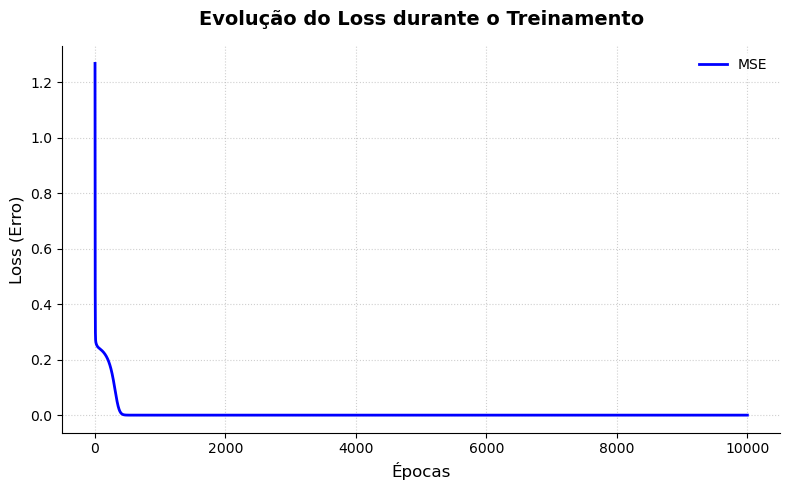

In [14]:
#nn = NeuralNetwork([2, 2, 1],ReLU,dReLU)
#nn = NeuralNetwork([2, 2, 1])
nn = NeuralNetwork([2, 2, 1],tanhp,dtanh)
# Entradas (Batch de 4 exemplos)
X = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

# Respostas Esperadas (XOR)
Y = [
    [0],
    [1],
    [1],
    [0]
]

print("Treinando a rede...")
nn.train(X, Y, epochs=10000, learning_rate=0.1, debug=False)

print("\nResultados Finais Pós-Treinamento:")
previsoes = nn.forward(X).T # .T apenas para printar bonitinho na tela
print(np.round(previsoes, 3))

nn.show_results() 

# Desafio de aprender a criar fronteiras com a rede neural que criei

Este é um desafio clássico porque os dados não são linearmente separáveis. Você não consegue passar uma régua (uma linha reta) e deixar os "zeros" de um lado e os "uns" do outro. Para resolver isso, a sua rede neural é obrigada a usar as camadas ocultas para "aprender" a equação do círculo, criando uma fronteira de decisão curva.Se a rede acertar, ela terá aprendido que:Se $\sqrt{x^2 + y^2} < 0.5$, então a resposta é 0; caso contrário, é 1.

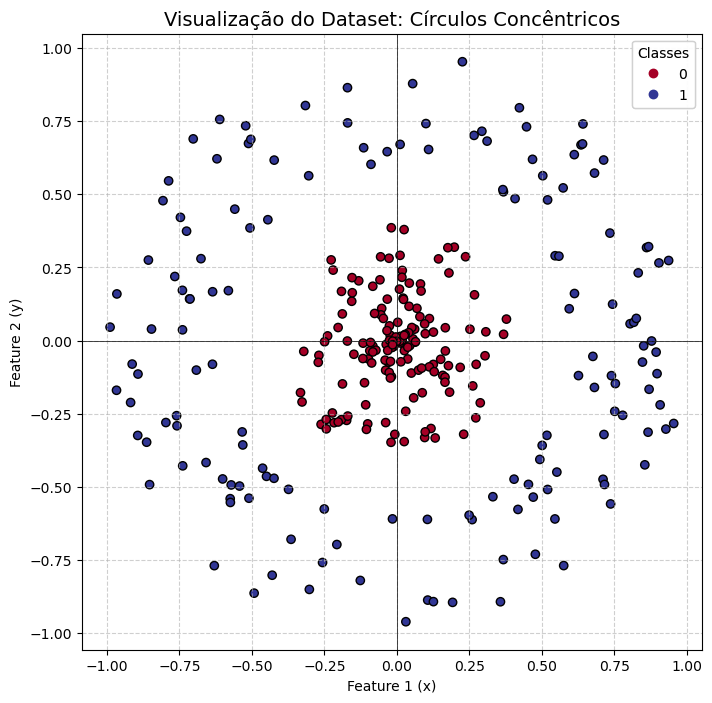

In [19]:
np.random.seed(42)
n_samples = 300 

# Criando pontos aleatórios que estejam num "círculo interno" de raio até 0.4
r_inner = np.random.uniform(0.0,0.4,n_samples//2)
theta_inner = np.random.uniform(0, 2*np.pi, n_samples//2)
X_inner = np.stack([r_inner*np.cos(theta_inner),r_inner*np.sin(theta_inner)],axis=1)
Y_inner = np.zeros((n_samples // 2,1)) # 0 -> Informa que está no círculo interno. É o rótulo

# Criando pontos aleatórios que estejam num "círculo externo" de raio entre 0.6 e 1.0
r_outer = np.random.uniform(0.6, 1.0, n_samples // 2)
theta_outer = np.random.uniform(0, 2 * np.pi, n_samples // 2)
X_outer = np.stack([r_outer * np.cos(theta_outer), r_outer * np.sin(theta_outer)], axis=1)
Y_outer = np.ones((n_samples // 2, 1)) # Informa que está no círculo externo. É o rótulo

# Criando as matrizes que serão utilizadas no treinamento onde X são os pontos e Y os rótulos dos pontos
X = np.vstack([X_inner, X_outer])
Y = np.vstack([Y_inner, Y_outer])

#plotando os valores
plt.figure(figsize=(8,8))

# X[:, 0] pega a primeira coluna (eixo x)
# X[:, 1] pega a segunda coluna (eixo y)
# c=Y.flatten() usa os rótulos para colorir os pontos
# cmap='RdYlBu' define um mapa de cores (Red/Yellow/Blue)
scatter = plt.scatter(X[:,0], X[:,1], c=Y.flatten(), cmap='RdYlBu', edgecolors='k')

#legenda
legend1 = plt.legend(*scatter.legend_elements(), title='Classes')
plt.gca().add_artist(legend1)

# Customização visual
plt.title("Visualização do Dataset: Círculos Concêntricos", fontsize=14)
plt.xlabel("Feature 1 (x)")
plt.ylabel("Feature 2 (y)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)

# Exibir
plt.show()


Treinando a rede no desafio dos círculos...


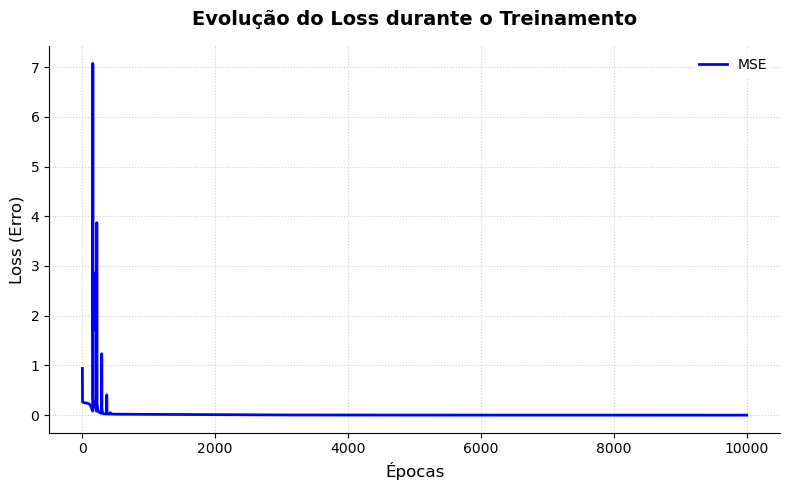

In [74]:
#Instanciando a rede que criei
nn = NeuralNetwork([2,8,4,1], activate_function=tanhp, d_activate_function=dtanh)
#nn = NeuralNetwork([2,8,4,1], activate_function=sigmoid, d_activate_function=dsigmoid)
print("Treinando a rede no desafio dos círculos...")
# 5000 épocas são suficientes com uma boa taxa de aprendizado
nn.train(X,Y, epochs=10000, learning_rate = 0.3, debug = False)

nn.show_results()

In [75]:
point1 = [[0.5, 0.5]]
point2 = [[1, 1]]
print(nn.forward(point1))
print(nn.forward(point2))
#Valor próximo de 0 -> Dentro
#Valor próximo de 1 -> Fora

[[1.01152769]]
[[0.99531034]]


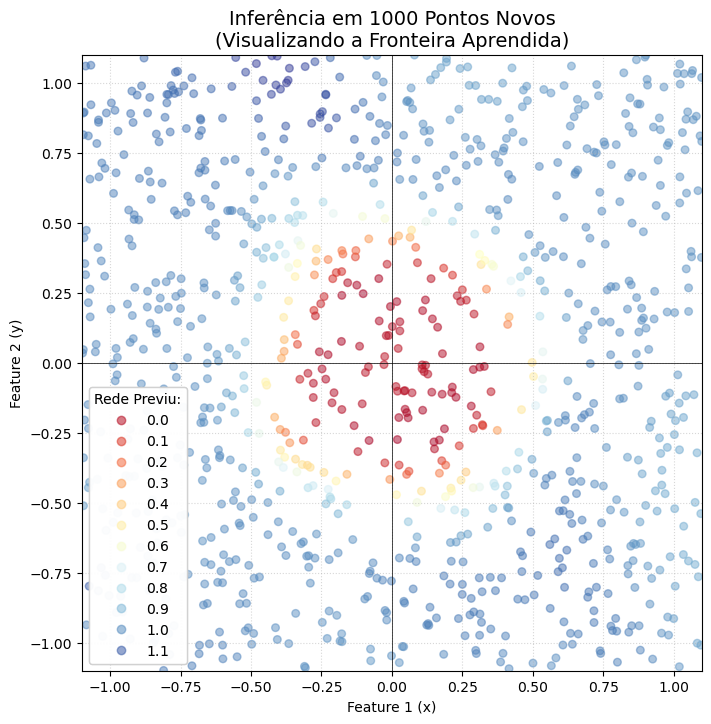

In [79]:
# Gerando vários dados fora uniformemente distribuiídos dos de treino.

#  Gerar novos pontos aleatórios (Inferência)
np.random.seed(12) # Seed diferente do treino para garantir pontos novos
num_novos_pontos = 1000

X_novos = np.random.uniform(-1.1, 1.1, (num_novos_pontos, 2))

# Previsões da rede
previsoes = nn.forward(X_novos)
#previsoes = np.where(previsoes < 0.5, 0, 1)

# Assumir para plot que se x <0.5 dentro e se x >0.5fora.
plt.figure(figsize=(8,8))

scatter_novos = plt.scatter(X_novos[:, 0], X_novos[:, 1], 
                             c=previsoes.flatten(), 
                             cmap='RdYlBu', # Mesma escala de cores (Vermelho/Azul)
                             s=30, alpha=0.5, marker='o', label='Pontos de Inferência')

legend1 = plt.legend(*scatter_novos.legend_elements(), title="Rede Previu:")
plt.gca().add_artist(legend1)

plt.title(f"Inferência em {num_novos_pontos} Pontos Novos\n(Visualizando a Fronteira Aprendida)", fontsize=14)
plt.xlabel("Feature 1 (x)")
plt.ylabel("Feature 2 (y)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()

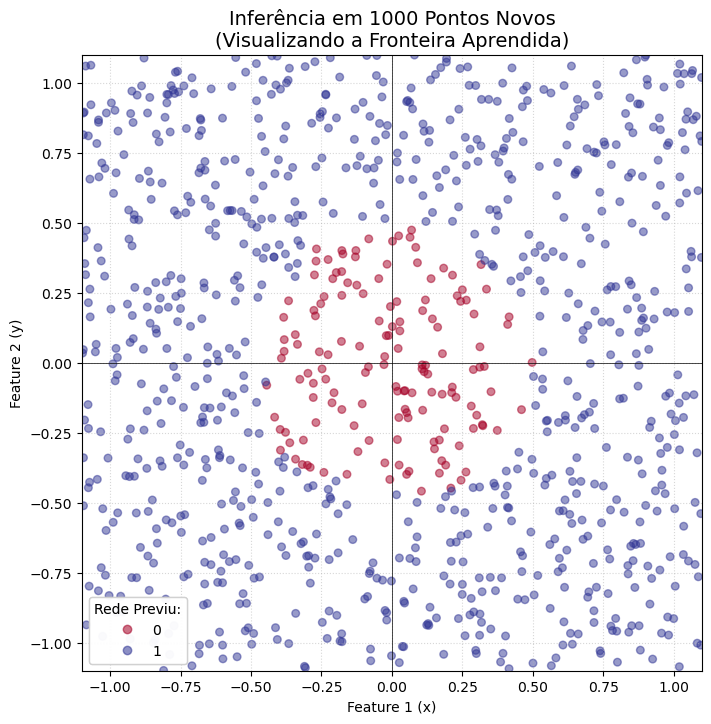

In [81]:
# Gerando vários dados fora uniformemente distribuiídos dos de treino.

#  Gerar novos pontos aleatórios (Inferência)
np.random.seed(12) # Seed diferente do treino para garantir pontos novos
num_novos_pontos = 1000

X_novos = np.random.uniform(-1.1, 1.1, (num_novos_pontos, 2))

# Previsões da rede
previsoes = nn.forward(X_novos)
previsoes = np.where(previsoes < 0.5, 0, 1)

# Assumir para plot que se x <0.5 dentro e se x >0.5fora.
plt.figure(figsize=(8,8))

scatter_novos = plt.scatter(X_novos[:, 0], X_novos[:, 1], 
                             c=previsoes.flatten(), 
                             cmap='RdYlBu', # Mesma escala de cores (Vermelho/Azul)
                             s=30, alpha=0.5, marker='o', label='Pontos de Inferência')

legend1 = plt.legend(*scatter_novos.legend_elements(), title="Rede Previu:")
plt.gca().add_artist(legend1)

plt.title(f"Inferência em {num_novos_pontos} Pontos Novos\n(Visualizando a Fronteira Aprendida)", fontsize=14)
plt.xlabel("Feature 1 (x)")
plt.ylabel("Feature 2 (y)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle=':', alpha=0.5)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.show()